# AVIRENZA Technologies – AI/ML Internship
## Task 3: Forest Fire Risk Prediction Using Machine Learning
**Student:** Tharani Natarajan  
**College:** IFET College of Engineering  
**Department:** Artificial Intelligence and Data Science  
**Task Type:** Supervised Machine Learning – Classification (Intermediate)



## 1. Project Objective
The primary objective of this project is to build a professional, leak-free supervised machine learning classification system that predicts whether historical forest conditions were associated with a fire occurrence (`fire_occurrence`) based on environmental and meteorological indicators.



## 2. Problem Statement
Forest fires are severe natural phenomena influenced by complex weather variables such as temperature, relative humidity, wind speed, and fuel moisture codes. 

In this project, we formulate an educational supervised classification task using the official UCI Forest Fires dataset. The goal is to evaluate how well standard classifiers (**Logistic Regression** and **Random Forest**) can distinguish between fire and non-fire conditions using historical meteorological observations.

> **Note:** This project is an educational machine learning analysis and is not an operational real-time wildfire early warning system.



## 3. Dataset Information
- **Dataset:** UCI Forest Fires Dataset
- **Official Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires)
- **Study Region:** Montesinho Natural Park, Portugal (Cortez & Morais, 2007)
- **Attributes:** 13 variables (Spatial coords `X`, `Y`; Temporal `month`, `day`; FWI components `FFMC`, `DMC`, `DC`, `ISI`; Weather `temp`, `RH`, `wind`, `rain`; Target source `area`).



## 4. Import Libraries and Setup Environment


In [1]:
import os
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline
print("All libraries imported successfully!")



All libraries imported successfully!


## 5. Load the Dataset


In [2]:
# Locate data file relative to notebook
data_path = Path('../data/forestfires.csv')
if not data_path.exists():
    data_path = Path('data/forestfires.csv')

df_raw = pd.read_csv(data_path)
print(f"Dataset loaded with {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")
df_raw.head()



Dataset loaded with 517 rows and 13 columns.


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## 6. Initial Data Inspection


In [3]:
print("--- First 5 Rows ---")
display(df_raw.head())

print("--- Last 5 Rows ---")
display(df_raw.tail())

print("--- Dataset Info ---")
df_raw.info()

print("--- Numerical Summary ---")
display(df_raw.describe())

print("--- Categorical Summary ---")
display(df_raw.describe(include=['object']))



--- First 5 Rows ---


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


--- Last 5 Rows ---


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00
516,6,3,nov,tue,79.5,3.0,106.7,1.1,11.8,31,4.5,0.0,0.00


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
--- Numerical Summary ---


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


--- Categorical Summary ---


,month,day
count,517,517
unique,12,7
top,aug,sun
freq,184,95


## 7. Data Quality & Cleaning Analysis


In [4]:
# Missing value check
print("Missing values per column:")
print(df_raw.isnull().sum())

# Duplicate check
exact_dups = df_raw.duplicated().sum()
print(f"\nExact duplicate rows: {exact_dups}")

# Drop duplicate rows for clean analysis
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Cleaned dataset shape: {df.shape} (Removed {exact_dups} duplicate records)")



Missing values per column:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Exact duplicate rows: 4
Cleaned dataset shape: (513, 13) (Removed 4 duplicate records)


## 8. Target Variable Creation & Target Leakage Prevention
We map the continuous `area` column to a binary target `fire_occurrence`:
- `area > 0`  -> `1` (Burned area recorded)
- `area == 0` -> `0` (No burned area recorded)

**Critical:** The `area` column is dropped from the input feature set ($X$) to strictly prevent target leakage.



In [5]:
# Create binary target
y = (df['area'] > 0).astype(int)
y.name = 'fire_occurrence'

# Feature matrix without 'area'
X = df.drop(columns=['area'])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nTarget Value Counts:")
print(y.value_counts())
print("\nTarget Value Percentages:")
print((y.value_counts(normalize=True) * 100).round(2))



Feature matrix shape: (513, 12)
Target vector shape: (513,)

Target Value Counts:
fire_occurrence
1    269
0    244
Name: count, dtype: int64

Target Value Percentages:
fire_occurrence
1    52.44
0    47.56
Name: proportion, dtype: float64


## 9. Feature Group Identification


In [6]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Features ({len(numerical_features)}):", numerical_features)
print(f"Categorical Features ({len(categorical_features)}):", categorical_features)



Numerical Features (10): ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
Categorical Features (2): ['month', 'day']


## 10. Exploratory Data Analysis (EDA)


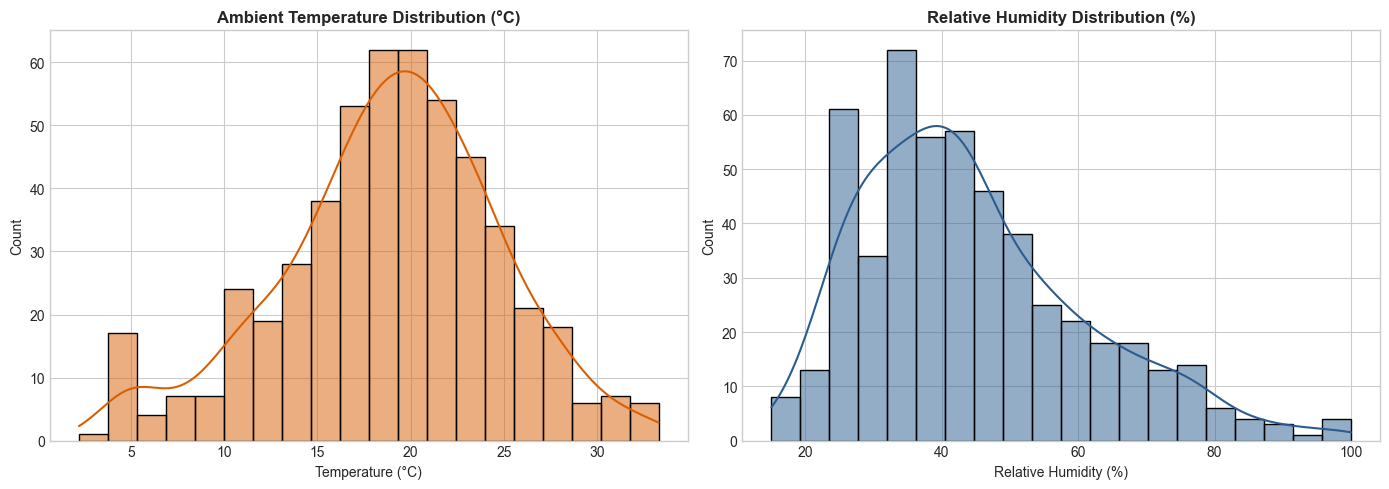

In [7]:
# 1. Temperature & Humidity Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['temp'], kde=True, ax=axes[0], color='#d95f02', bins=20)
axes[0].set_title('Ambient Temperature Distribution (°C)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')

sns.histplot(df['RH'], kde=True, ax=axes[1], color='#2b5c8f', bins=20)
axes[1].set_title('Relative Humidity Distribution (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Relative Humidity (%)')

plt.tight_layout()
plt.show()



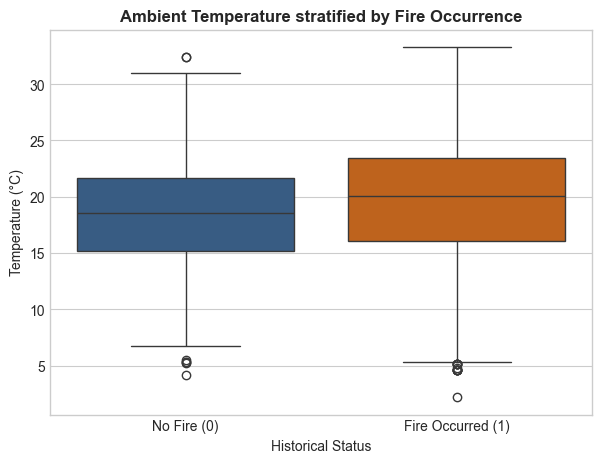

In [8]:
# 2. Temperature by Fire Occurrence
plt.figure(figsize=(7, 5))
df_plot = df.copy()
df_plot['fire_status'] = np.where(df_plot['area'] > 0, 'Fire Occurred (1)', 'No Fire (0)')

sns.boxplot(x='fire_status', y='temp', data=df_plot, palette=['#2b5c8f', '#d95f02'])
plt.title('Ambient Temperature stratified by Fire Occurrence', fontsize=12, fontweight='bold')
plt.xlabel('Historical Status')
plt.ylabel('Temperature (°C)')
plt.show()



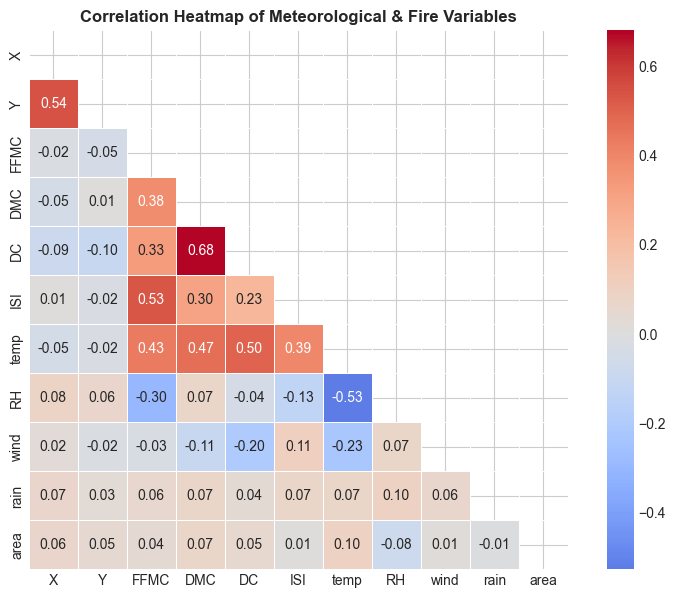

In [9]:
# 3. Correlation Heatmap
plt.figure(figsize=(10, 7))
corr = df[numerical_features + ['area']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Meteorological & Fire Variables', fontsize=12, fontweight='bold')
plt.show()



## 11. Class Distribution Analysis


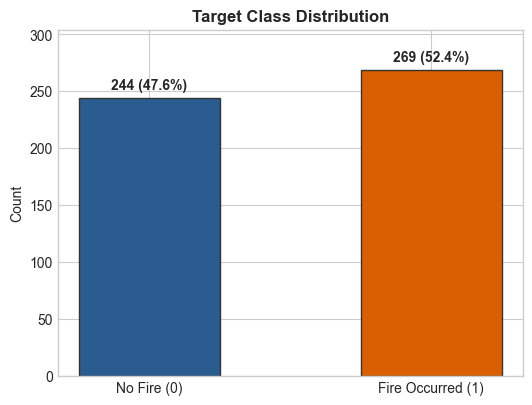

In [10]:
plt.figure(figsize=(6, 4.5))
counts = y.value_counts().sort_index()
bars = plt.bar(['No Fire (0)', 'Fire Occurred (1)'], counts.values, color=['#2b5c8f', '#d95f02'], width=0.5, edgecolor='#333333')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 5, f"{h} ({h/len(y)*100:.1f}%)", ha='center', va='bottom', fontweight='bold')

plt.title('Target Class Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Count')
plt.ylim(0, max(counts.values) + 35)
plt.show()



## 12. Stratified Train-Test Split
We split the dataset into 80% training and 20% test sets using `stratify=y` to preserve class proportions.



In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set : {X_test.shape[0]} samples")
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True).round(4))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True).round(4))



Training set: 410 samples
Testing set : 103 samples

Train target distribution:
 fire_occurrence
1    0.5244
0    0.4756
Name: proportion, dtype: float64

Test target distribution:
 fire_occurrence
1    0.5243
0    0.4757
Name: proportion, dtype: float64


## 13. Preprocessing Pipeline Architecture
Constructing a `ColumnTransformer` to handle:
- **Numerical Features:** Median Imputation -> StandardScaler
- **Categorical Features:** Most-Frequent Imputation -> OneHotEncoder



In [12]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
], remainder='drop')

print("Preprocessing pipeline built successfully.")



Preprocessing pipeline built successfully.


## 14. Model 1 – Logistic Regression Classifier


In [13]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")



Logistic Regression trained successfully.


## 15. Model 2 – Random Forest Classifier


In [14]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Classifier trained successfully.")



Random Forest Classifier trained successfully.


## 16. Comprehensive Model Evaluation


In [15]:
def compute_metrics(y_true, y_pred, y_proba, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

lr_metrics = compute_metrics(y_test, y_pred_lr, y_proba_lr, "Logistic Regression")
rf_metrics = compute_metrics(y_test, y_pred_rf, y_proba_rf, "Random Forest")

results_df = pd.DataFrame([lr_metrics, rf_metrics])
display(results_df.round(4))

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, digits=4))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, digits=4))



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.5437,0.5556,0.6481,0.5983,0.6096
1,Random Forest,0.6408,0.6491,0.6852,0.6667,0.7037



--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0     0.5250    0.4286    0.4719        49
           1     0.5556    0.6481    0.5983        54

    accuracy                         0.5437       103
   macro avg     0.5403    0.5384    0.5351       103
weighted avg     0.5410    0.5437    0.5382       103


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0     0.6304    0.5918    0.6105        49
           1     0.6491    0.6852    0.6667        54

    accuracy                         0.6408       103
   macro avg     0.6398    0.6385    0.6386       103
weighted avg     0.6402    0.6408    0.6400       103



## 17. Confusion Matrix Visualization


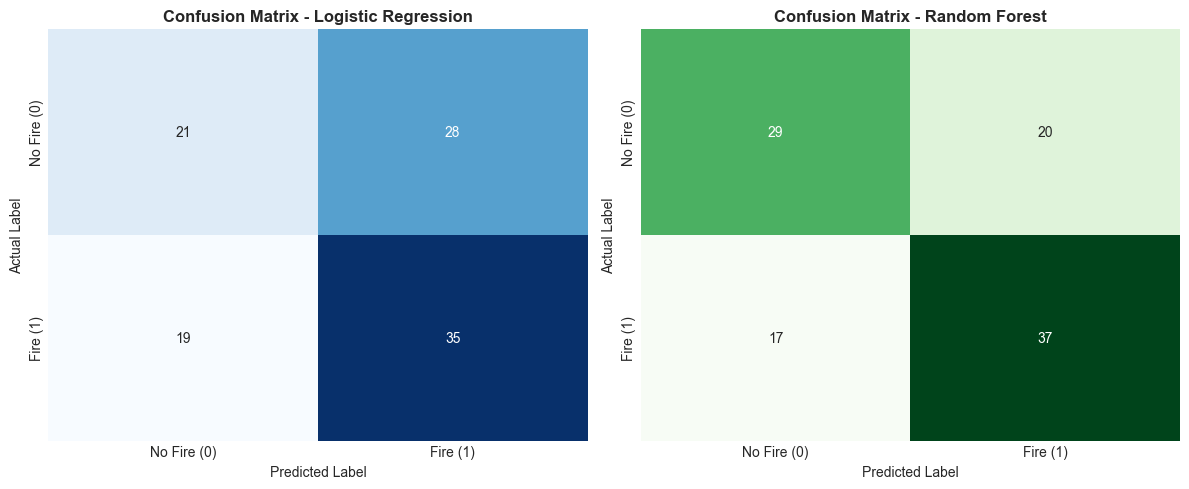

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['No Fire (0)', 'Fire (1)'], yticklabels=['No Fire (0)', 'Fire (1)'])
axes[0].set_title('Confusion Matrix - Logistic Regression', fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['No Fire (0)', 'Fire (1)'], yticklabels=['No Fire (0)', 'Fire (1)'])
axes[1].set_title('Confusion Matrix - Random Forest', fontweight='bold')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## 18. ROC Curve Comparison


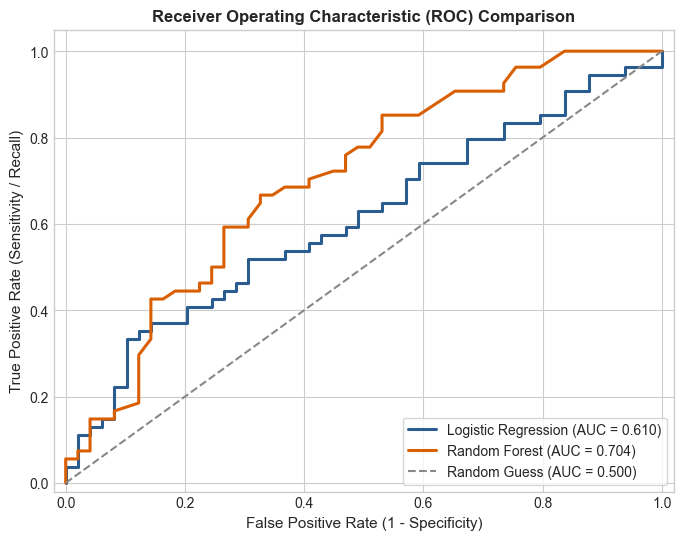

In [17]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='#2b5c8f', lw=2.2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, color='#d95f02', lw=2.2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='#888888', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.500)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Comparison', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', frameon=True)
plt.show()



## 19. Random Forest Feature Importance


Top 10 Transformed Features by Importance:


,Feature,Importance
0,temp,0.1314
1,RH,0.1234
2,DC,0.0976
3,DMC,0.0959
4,ISI,0.0885
5,wind,0.0880
6,X,0.0842
7,FFMC,0.0789
8,Y,0.0596
9,day_fri,0.0150


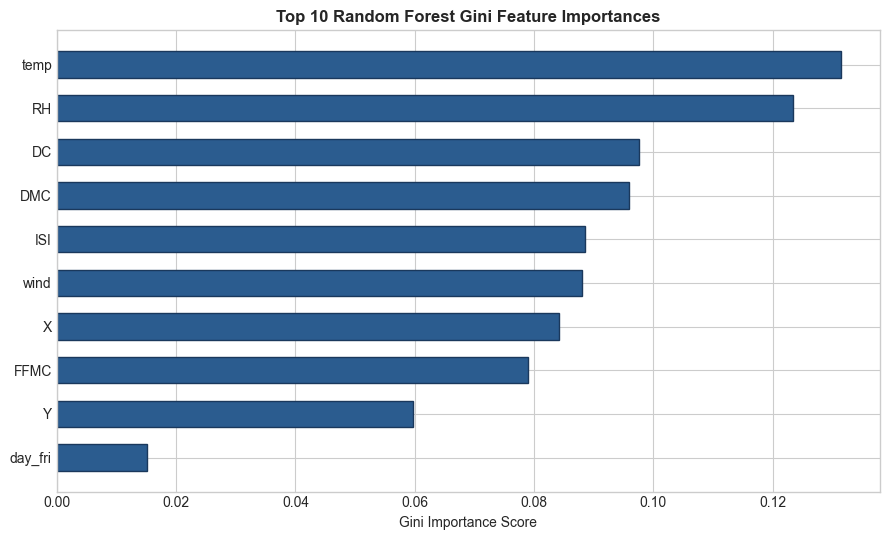

In [18]:
# Extract transformed feature names
transformed_names = preprocessor.get_feature_names_out()
clean_names = [f.replace('num__', '').replace('cat__', '') for f in transformed_names]
rf_importances = rf_pipeline.named_steps['classifier'].feature_importances_

fi_df = pd.DataFrame({'Feature': clean_names, 'Importance': rf_importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 10 Transformed Features by Importance:")
display(fi_df.head(10).round(4))

plt.figure(figsize=(9, 5.5))
top10 = fi_df.head(10).sort_values(by='Importance', ascending=True)
plt.barh(top10['Feature'], top10['Importance'], color='#2b5c8f', edgecolor='#1a385c', height=0.6)
plt.title('Top 10 Random Forest Gini Feature Importances', fontsize=12, fontweight='bold')
plt.xlabel('Gini Importance Score')
plt.tight_layout()
plt.show()



## 20. 5-Fold Stratified Cross-Validation


In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_f1 = cross_val_score(lr_pipeline, X_train, y_train, cv=skf, scoring='f1')
rf_cv_f1 = cross_val_score(rf_pipeline, X_train, y_train, cv=skf, scoring='f1')

lr_cv_auc = cross_val_score(lr_pipeline, X_train, y_train, cv=skf, scoring='roc_auc')
rf_cv_auc = cross_val_score(rf_pipeline, X_train, y_train, cv=skf, scoring='roc_auc')

cv_summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'CV_F1_Mean': lr_cv_f1.mean(),
        'CV_F1_Std': lr_cv_f1.std(),
        'CV_ROC_AUC_Mean': lr_cv_auc.mean(),
        'CV_ROC_AUC_Std': lr_cv_auc.std()
    },
    {
        'Model': 'Random Forest',
        'CV_F1_Mean': rf_cv_f1.mean(),
        'CV_F1_Std': rf_cv_f1.std(),
        'CV_ROC_AUC_Mean': rf_cv_auc.mean(),
        'CV_ROC_AUC_Std': rf_cv_auc.std()
    }
])
display(cv_summary.round(4))



,Model,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.5566,0.0412,0.4739,0.0564
1,Random Forest,0.5522,0.0354,0.5398,0.0314


## 21. Overall Model Comparison Summary


In [20]:
final_comp = results_df.merge(cv_summary, on='Model')
display(final_comp.round(4))



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.5437,0.5556,0.6481,0.5983,0.6096,0.5566,0.0412,0.4739,0.0564
1,Random Forest,0.6408,0.6491,0.6852,0.6667,0.7037,0.5522,0.0354,0.5398,0.0314


## 22. Key Findings
1. **Model Performance:** Random Forest achieved higher test accuracy (64.08%) and ROC-AUC (0.7037) compared to Logistic Regression (Accuracy: 54.37%, ROC-AUC: 0.6096).
2. **Predictive Drivers:** Temperature (`temp`), Relative Humidity (`RH`), and Drought Code (`DC`) were the top three most influential predictive variables.
3. **Cross-Validation Consistency:** 5-fold cross-validation demonstrated steady F1 scores (~0.55) across folds, confirming no extreme overfitting.



## 23. Limitations
- **Data Footprint:** 513 records from a single natural park in Portugal.
- **Derived Target:** Discretizing continuous burned area into binary values simplifies complex fire intensity dynamics.
- **Educational Context:** Model outputs reflect statistical patterns rather than real-time operational wildfire dispatch mechanisms.



## 24. Conclusion & Model Export


In [21]:
# Export model pipeline via Joblib
output_model_path = Path('../outputs/models/random_forest_fire_model.pkl')
if not output_model_path.parent.exists():
    output_model_path = Path('outputs/models/random_forest_fire_model.pkl')

output_model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(rf_pipeline, output_model_path)
print(f"End-to-end model pipeline successfully saved to {output_model_path}")

# Verify reload
loaded_model = joblib.load(output_model_path)
sample_test = X_test.iloc[:3]
sample_preds = loaded_model.predict(sample_test)
print(f"Verification: Loaded model generated predictions: {sample_preds.tolist()}")



End-to-end model pipeline successfully saved to ..\outputs\models\random_forest_fire_model.pkl
Verification: Loaded model generated predictions: [1, 1, 1]
